<a href="https://colab.research.google.com/github/kietietv/TH_Deep_Learning/blob/main/Tu%E1%BA%A7n_03_Thuchanh_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bài tập

### Bài 1: Cài đặt ANN nhận dạng ảnh CIFAR-10

In [ ]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Flatten, Dense, Dropout
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping

# 1. Nạp và tiền xử lý dữ liệu CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 2. Xây dựng mô hình thuần ANN
model_ann_cifar = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

# 3. Biên dịch và Huấn luyện
model_ann_cifar.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Bắt đầu huấn luyện ANN cho CIFAR-10...")
model_ann_cifar.fit(X_train, y_train, epochs=30, batch_size=128,
                    validation_data=(X_test, y_test), callbacks=[early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Bắt đầu huấn luyện ANN cho CIFAR-10...
Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.2742 - loss: 1.9942 - val_accuracy: 0.3646 - val_loss: 1.7766
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3381 - loss: 1.8315 - val_accuracy: 0.3857 - val_loss: 1.7255
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3581 - loss: 1.7778 - val_accuracy: 0.4117 - val_loss: 1.6689
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3727 - loss: 1.7415 - val_accuracy: 0.4105 - val_loss: 1.6632
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3799 - loss: 1.7195 - val_accuracy: 0.4342 - val_loss: 1.6302
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3925 - loss: 1.6852 - val_accuracy: 0.4373 - val_loss: 1.5981
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4016 - loss: 1.6615 - val_accuracy: 0.4178 - val_loss: 1.6133
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
Kết quả: Tàu thủy


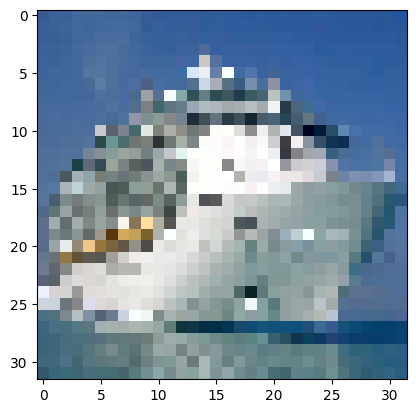

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Danh sách 10 nhãn của CIFAR-10
cifar_labels = ['Máy bay', 'Ô tô', 'Chim', 'Mèo', 'Hươu', 'Chó', 'Ếch', 'Ngựa', 'Tàu thủy', 'Xe tải']

# 1. Tải ảnh và xử lý (ANN nhận input phẳng nên chỉ cần resize)
img_path = '/content/test_cifar.jpg'
img = image.load_img(img_path, target_size=(32, 32))
img_array = image.img_to_array(img) / 255.0
img_array = img_array.reshape(1, 32, 32, 3) # ANN sẽ flatten trong model

# 2. Dự đoán
pred = model_ann_cifar.predict(img_array)
print(f"Kết quả: {cifar_labels[np.argmax(pred)]}")
plt.imshow(img)
plt.show()

In [ ]:
# Cài đặt kích thước ảnh về chuẩn 28x28
img_size = (28, 28)

# Load file ảnh từ máy/Colab, ép về dạng đen trắng (grayscale)
img = tf.keras.preprocessing.image.load_img(
    '/content/sample_data/dress.jpg',
    color_mode='grayscale',
    target_size=img_size
)

# Chuyển ảnh thành mảng ma trận số (Numpy array)
img_array = tf.keras.preprocessing.image.img_to_array(img)

# Loại bỏ các chiều thừa, ép phẳng (flatten) ảnh thành 1 vector kích thước (784,)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array, (784,))

# Thêm 1 chiều đại diện cho "batch size" (số lượng ảnh truyền vào 1 lúc)
# Kết quả trở thành (1, 784) - vì Keras luôn yêu cầu dữ liệu dự báo phải có chiều batch
img_array = tf.expand_dims(img, 0)
img_array = tf.convert_to_tensor(img_array)
print("Kích thước mảng đưa vào dự báo:", img_array.shape)

# Thực hiện dự báo
img_predict = model.predict(img_array)
print("Xác suất dự báo:", img_predict)

# Lấy nhãn có xác suất cao nhất
score = np.argmax(img_predict)
print("Kết quả (Nhãn):", score)

Kích thước mảng đưa vào dự báo: (1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Xác suất dự báo: [[4.8546008e-05 1.1069498e-02 9.0918135e-08 9.8252493e-01 6.3185943e-03
  0.0000000e+00 3.8366521e-05 0.0000000e+00 2.3040380e-08 0.0000000e+00]]
Kết quả (Nhãn): 3


### Bài 2: Cài đặt ANN nhận dạng ảnh chữ viết số (MNIST Digits)

In [ ]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Flatten, Dense, Dropout
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping

# 1. Nạp dữ liệu số viết tay MNIST có sẵn
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 2. Xây dựng mô hình thuần ANN
model_ann_mnist = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# 3. Biên dịch và Huấn luyện
model_ann_mnist.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Bắt đầu huấn luyện ANN cho MNIST...")
model_ann_mnist.fit(X_train, y_train, epochs=20, batch_size=128,
                    validation_data=(X_test, y_test), callbacks=[early_stop])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Bắt đầu huấn luyện ANN cho MNIST...
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9117 - loss: 0.2985 - val_accuracy: 0.9633 - val_loss: 0.1194
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9633 - loss: 0.1218 - val_accuracy: 0.9706 - val_loss: 0.0904
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9730 - loss: 0.0878 - val_accuracy: 0.9758 - val_loss: 0.0768
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9783 - loss: 0.0686 - val_accuracy: 0.9781 - val_loss: 0.0703
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9823 - loss: 0.0565 - val_accuracy: 0.9780 - val_loss: 0.0677
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9840 - loss: 0.0496 - val_accuracy: 0.9791 - val_loss: 0.0686
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9858 - loss: 0.0419 - val_accuracy: 0.9794 - val_loss: 0.0710
Epoch 8/20
469/46

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
Kết quả: Số 5


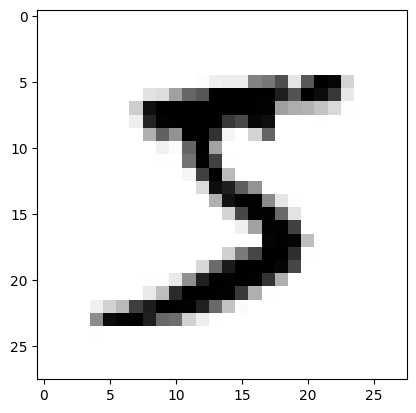

In [ ]:
# 1. Tải ảnh và xử lý (color_mode='grayscale')
img_path = '/content/test_mnist_image.png'
img = image.load_img(img_path, target_size=(28, 28), color_mode='grayscale')

# 2. Chuyển thành mảng và chuẩn hóa (pixel 0-255 -> 0-1)
img_array = image.img_to_array(img) / 255.0
img_array = img_array.reshape(1, 28, 28) # Phù hợp với Flatten(input_shape=(28, 28))

# 3. Dự đoán
pred = model_ann_mnist.predict(img_array)
print(f"Kết quả: Số {np.argmax(pred)}")
plt.imshow(img, cmap='gray')
plt.show()

### Bài 3: Cài đặt ANN nhận dạng Cat hoặc Dog

In [ ]:
import os
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Flatten, Dense, Dropout
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping
import tensorflow_datasets as tfds

# 1. Nạp và tiền xử lý dữ liệu từ tensorflow_datasets
(raw_train, raw_test), metadata = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True,
)

IMG_WIDTH = 64
IMG_HEIGHT = 64

def format_example(image, label):
    image = tf.cast(image, tf.float32)
    image = image / 255.0
    image = tf.image.resize(image, (IMG_WIDTH, IMG_HEIGHT))
    return image, label

BATCH_SIZE = 64

SHUFFLE_BUFFER_SIZE = 10000
PREFETCH_BUFFER_SIZE = tf.data.AUTOTUNE

train_dataset = raw_train.map(format_example).shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE).prefetch(buffer_size=PREFETCH_BUFFER_SIZE)
test_dataset = raw_test.map(format_example).batch(BATCH_SIZE).prefetch(buffer_size=PREFETCH_BUFFER_SIZE)


# 3. Xây dựng mô hình thuần ANN
model_ann_catdog = Sequential([
    Flatten(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 4. Biên dịch và Huấn luyện
model_ann_catdog.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Bắt đầu huấn luyện ANN cho Cat/Dog...")
model_ann_catdog.fit(
    train_dataset,
    epochs=20,
    validation_data=test_dataset,
    callbacks=[early_stop]
)

Bắt đầu huấn luyện ANN cho Cat/Dog...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


291/291 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.5174 - loss: 0.8273 - val_accuracy: 0.5460 - val_loss: 0.6869
Epoch 2/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 36s 55ms/step - accuracy: 0.5344 - loss: 0.6876 - val_accuracy: 0.5361 - val_loss: 0.6897
Epoch 3/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.5212 - loss: 0.6904 - val_accuracy: 0.5374 - val_loss: 0.6866
Epoch 4/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 47s 74ms/step - accuracy: 0.5265 - loss: 0.6868 - val_accuracy: 0.5866 - val_loss: 0.6754
Epoch 5/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 33s 80ms/step - accuracy: 0.5530 - loss: 0.6822 - val_accuracy: 0.5978 - val_loss: 0.6751
Epoch 6/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.5491 - loss: 0.6828 - val_accuracy: 0.6094 - val_loss: 0.6681
Epoch 7/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.5659 - loss: 0.6761 - val_accuracy: 0.6122 - val_loss: 0.6628
Epoch 8/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.5638 - loss: 0.6777 - val_accurac

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
Xác suất: 0.4489
Kết quả: ĐÂY LÀ CON MÈO


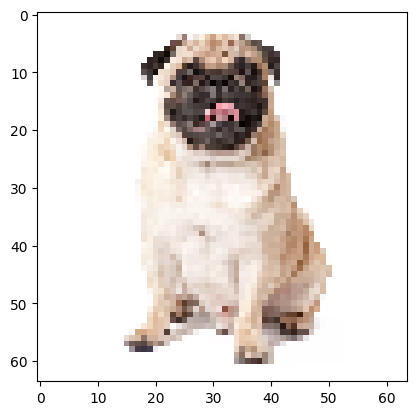

In [ ]:
# 1. Tải ảnh và resize
img_path = '/content/test_cat_or_dog.jpg'
img = image.load_img(img_path, target_size=(64, 64))
img_array = image.img_to_array(img) / 255.0
img_array = img_array.reshape(1, 64, 64, 3)

# 2. Dự đoán
pred = model_ann_catdog.predict(img_array)
score = pred[0][0]

# 3. Kết luận
print(f"Xác suất: {score:.4f}")
if score >= 0.5:
    print("Kết quả: ĐÂY LÀ CON CHÓ")
else:
    print("Kết quả: ĐÂY LÀ CON MÈO")
plt.imshow(img)
plt.show()

# Triển khai ANN mẫu Lab 2

In [ ]:
# Cài đặt và nạp các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense

# Thư viện hỗ trợ chuẩn hóa dữ liệu
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Tải bộ dataset Fashion MNIST
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()

print("Kích thước dữ liệu gốc:")
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

# Thay đổi hình dạng dữ liệu (Reshape) từ 3D sang 2D mảng
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

# Chuẩn hóa dữ liệu (Feature Scaling)
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('\nSố lượng nhãn (Classes):', len(np.unique(y_train)))
print('Các nhãn:', np.unique(y_train))

Kích thước dữ liệu gốc:
Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)

Số lượng nhãn (Classes): 10
Các nhãn: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
# Khởi tạo mô hình ANN
fashion_model = Sequential()

# Thêm lớp ẩn đầu tiên (Hidden layer)
# input_dim = 784 tương ứng với số pixel sau khi duỗi thẳng
fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

# Thêm lớp đầu ra (Output layer)
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch mô hình (Compile neural network)
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Hiển thị tóm tắt kiến trúc mạng
fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Quá trình huấn luyện sẽ được lưu vào biến model_fit để vẽ biểu đồ sau này
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8220 - loss: 0.5022 - val_accuracy: 0.8522 - val_loss: 0.3962
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8671 - loss: 0.3686 - val_accuracy: 0.8733 - val_loss: 0.3593
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8802 - loss: 0.3294 - val_accuracy: 0.8755 - val_loss: 0.3474
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8887 - loss: 0.3043 - val_accuracy: 0.8755 - val_loss: 0.3312
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8944 - loss: 0.2861 - val_accuracy: 0.8825 - val_loss: 0.3303
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8987 - loss: 0.2711 - val_accuracy: 0.8793 - val_loss: 0.3488
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9052 - loss: 0.2601 - val_accuracy: 0.8847 - val_loss: 0.3295
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9092 - loss: 0.2453 - 

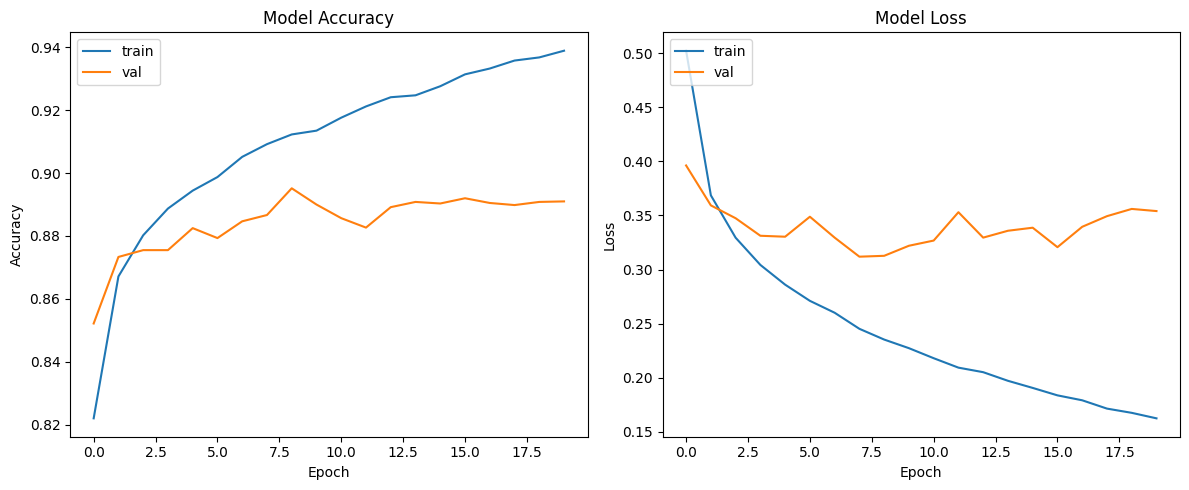


--- KẾT QUẢ DỰ BÁO ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mô hình dự báo nhãn: 5
Nhãn thực tế (True label): 5


In [ ]:
# Trực quan hóa độ chính xác (Accuracy)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='train')
plt.plot(model_fit.history['val_accuracy'], label='val')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Trực quan hóa độ mất mát (Loss)
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='train')
plt.plot(model_fit.history['val_loss'], label='val')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Dự báo thử với phần tử đầu tiên trong tập X_test
print("\n--- KẾT QUẢ DỰ BÁO ---")
prediction_0 = fashion_model.predict(X_test)[9999]
predicted_label_0 = np.argmax(prediction_0)
print(f"Mô hình dự báo nhãn: {predicted_label_0}")
print(f"Nhãn thực tế (True label): {y_test[9999]}")

# Triển khai ANN mẫu đọc dữ liệu từ file

In [ ]:
import pandas as pd
import numpy as np

# 1. Khai báo đường dẫn tới file CSV (trên Google Colab)
mnist_train_path = '/content/sample_data/fashion-mnist_train.csv'
mnist_test_path = '/content/sample_data/fashion-mnist_test.csv'

# 2. Đọc file CSV bằng Pandas
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)

print("Kích thước tập train ban đầu:", mnist_train.shape)

# 3. Tách dữ liệu thành X (đặc trưng) và y (nhãn)
# Lấy tất cả các dòng, và lấy từ cột thứ 1 (bỏ qua cột 0) đến hết
X_train = mnist_train.iloc[:, 1:]
X_test = mnist_test.iloc[:, 1:]
print("Kích thước X_train:", X_train.shape) # Kết quả sẽ là (60000, 784)

# Lấy tất cả các dòng, nhưng CHỈ lấy cột 0 (chứa nhãn từ 0 đến 9)
y_train = mnist_train.iloc[:, 0]
y_test = mnist_test.iloc[:, 0]

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Kích thước tập train ban đầu: (60000, 785)
Kích thước X_train: (60000, 784)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
import tensorflow as tf
from keras import Sequential
from keras.layers import Dense

# Khởi tạo mô hình
model = Sequential()

# X_train.shape[1] chính là 784
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch mô hình
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Bắt đầu huấn luyện (Fit)
model_fit = model.fit(X_train, y_train, epochs=30, verbose=1)

# Kiểm tra dự báo nhanh với phần tử đầu tiên trong tập Test
print("\nDự báo phần tử đầu tiên:", np.argmax(model.predict(X_test)[0]))
print("Nhãn thực tế:", y_test.iloc[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Dự báo phần tử đầu tiên: 0
Nhãn thực tế: 0


Đã tạo và lưu thành công file /content/sample_data/dress.jpg!


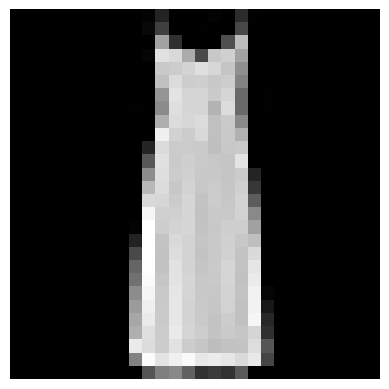

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Load lại data gốc để lấy ảnh 2D
fashion = tf.keras.datasets.fashion_mnist
(_, _), (X_test_img, y_test_label) = fashion.load_data()

# Tìm vị trí của bức ảnh đầu tiên có nhãn là 3 (Dress - Cái váy)
dress_index = np.where(y_test_label == 3)[0][0]

# Lấy bức ảnh đó ra
dress_image = X_test_img[dress_index]

# Lưu bức ảnh thành file dress.jpg vào đúng đường dẫn để test
plt.imsave('/content/sample_data/dress.jpg', dress_image, cmap='gray')

print("Đã tạo và lưu thành công file /content/sample_data/dress.jpg!")

# Hiển thị thử bức ảnh vừa lưu lên màn hình
plt.imshow(dress_image, cmap='gray')
plt.axis('off')
plt.show()